
 OVERALL UK MARKET CHANGE (2013-01 to latest available month)
House prices change: 72.82%
Annualized house price growth: 4.80%
Transaction count change: 380.47%
Transaction value change: 534.04%
GDP change: 20.17%

PERIOD SUMMARY
                         Period   Start     End  House price change (%)  Annualized house price growth (%)  Transaction count change (%)  Transaction value change (%)  GDP change (%)
Pre-pandemic growth (2013-2019) 2013-01 2019-12                   38.21                               4.79                        315.59                        752.33           15.66
      Pandemic boom (2020-2021) 2020-01 2021-12                   14.76                               7.45                         71.69                        103.62            3.59
 Post-2022 cooling / adjustment 2022-01 2024-09                    7.65                               2.80                          3.14                        -16.22            2.12

EXTREME HOUSING MARKET MOMENTS
Highe

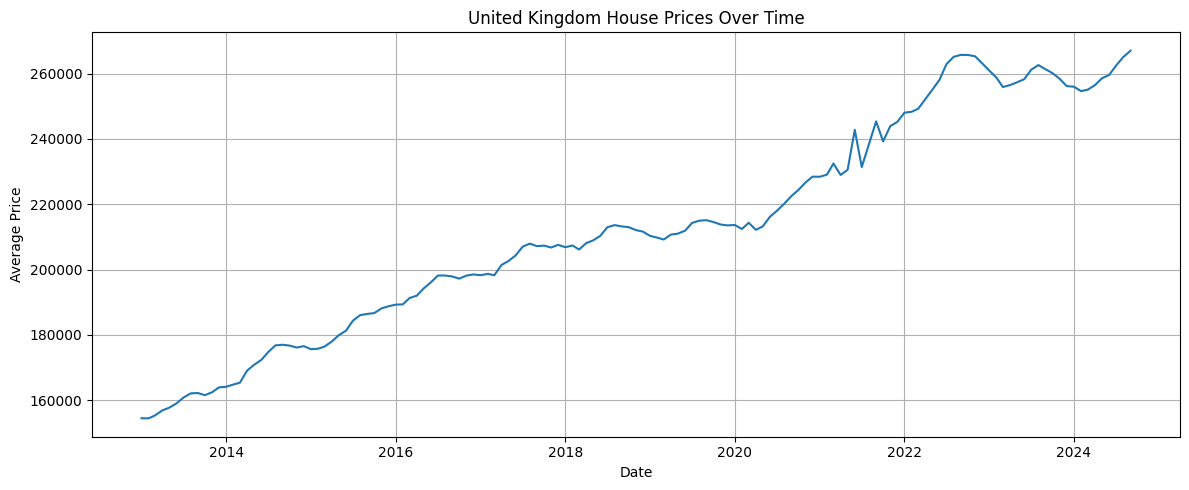

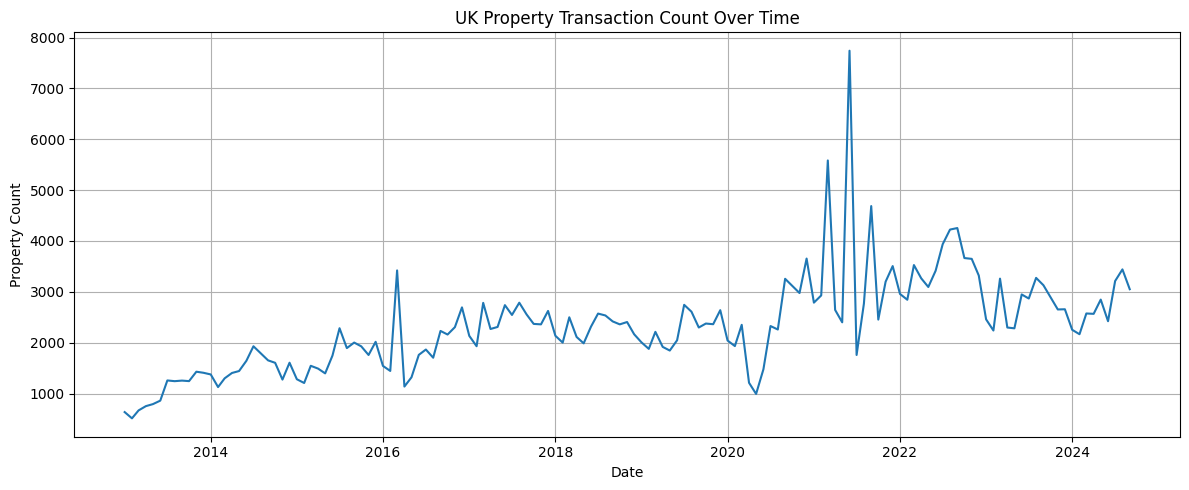

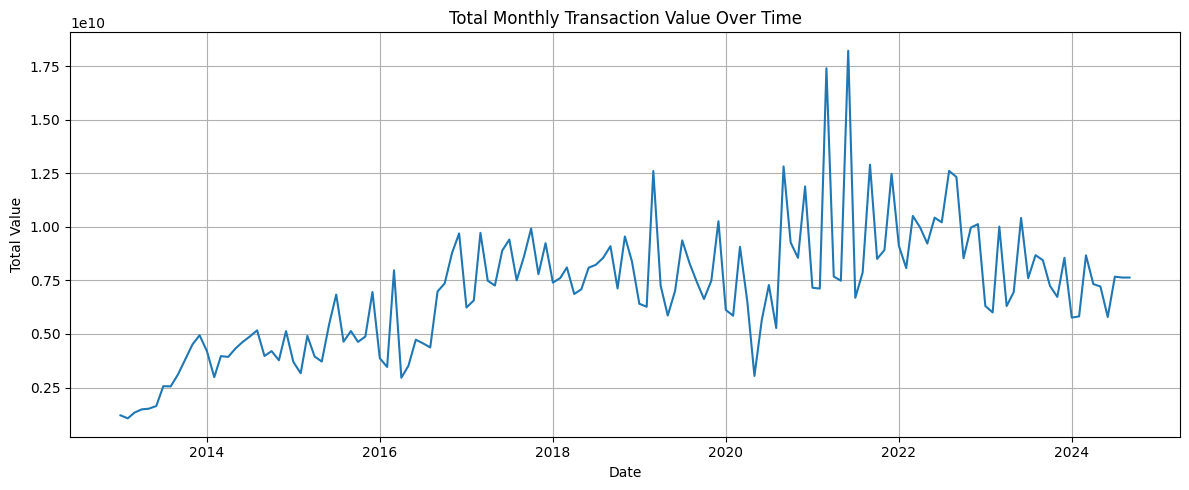

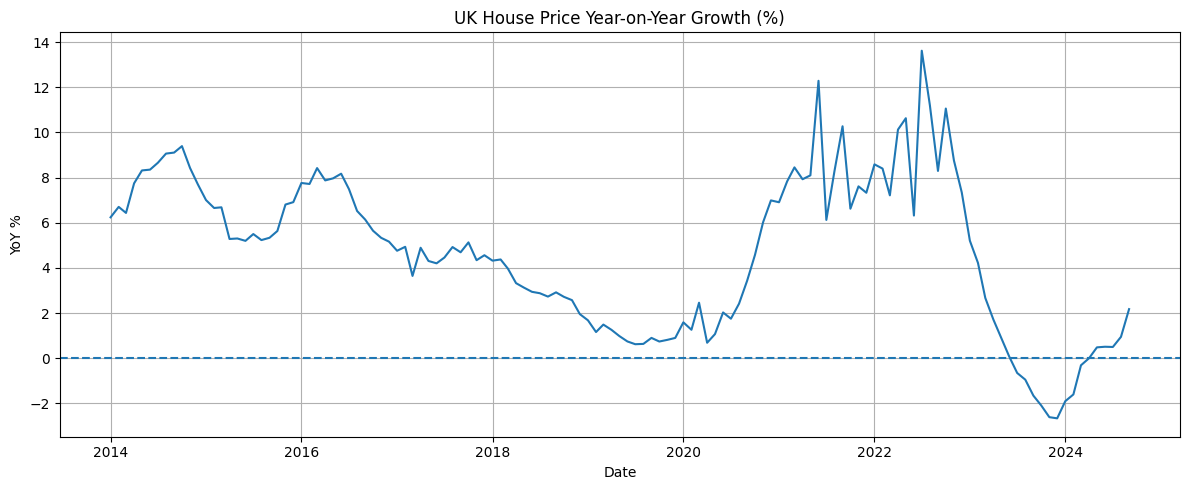

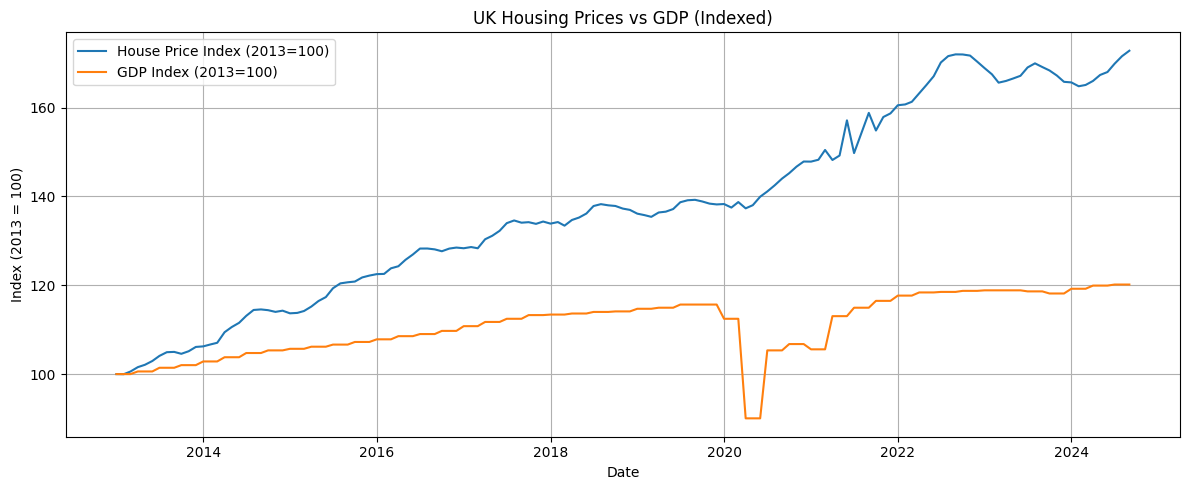

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# house prices index
hpi = pd.read_csv("cleaned_uk_houseprice_sheet2.csv")
hpi["Date"] = pd.to_datetime(hpi["Date"])
#clean data
hpi = hpi[["Date", "United Kingdom"]].dropna()
hpi = hpi.groupby("Date", as_index=False)["United Kingdom"].mean()
hpi = hpi.sort_values("Date")

# luxury transactions
transactions = pd.read_csv("price_paid_monthly.csv")
transactions["month"] = pd.to_datetime(transactions["month"])
transactions = transactions.sort_values("month")

# macro variables
macro = pd.read_csv("uk_stability_M.csv")
macro["month"] = pd.to_datetime(macro["month"])
macro = macro.sort_values("month")

#merging data by date
hpi = hpi[hpi["Date"] >= "2013-01-01"]
df = (hpi.merge(transactions, left_on="Date", right_on="month", how="inner").merge(macro, on="month", how="inner"))
df = df.drop(columns=["Date"])
df = df.sort_values("month").reset_index(drop=True)

# Year-on-year growth rates
df["hpi_yoy_pct"] = df["United Kingdom"].pct_change(12) * 100
df["transactions_yoy_pct"] = df["property_count"].pct_change(12) * 100
df["value_yoy_pct"] = df["total_value"].pct_change(12) * 100

# helper function for periods
def period_summary(data, start_date, end_date, label):
    temp = data[(data["month"] >= start_date) & (data["month"] <= end_date)].copy()
    first = temp.iloc[0]
    last = temp.iloc[-1]
    months = (last["month"].year - first["month"].year) * 12 + (last["month"].month - first["month"].month)
    years = months / 12 if months > 0 else 1
    hpi_change = (last["United Kingdom"] / first["United Kingdom"] - 1) * 100
    hpi_cagr = ((last["United Kingdom"] / first["United Kingdom"]) ** (1 / years) - 1) * 100 if months > 0 else np.nan
    transaction_change = (last["property_count"] / first["property_count"] - 1) * 100
    value_change = (last["total_value"] / first["total_value"] - 1) * 100
    gdp_change = (last["real_gdp_cvm"] / first["real_gdp_cvm"] - 1) * 100
    return {
        "Period": label,
        "Start": first["month"].strftime("%Y-%m"),
        "End": last["month"].strftime("%Y-%m"),
        "House price change (%)": round(hpi_change, 2),
        "Annualized house price growth (%)": round(hpi_cagr, 2),
        "Transaction count change (%)": round(transaction_change, 2),
        "Transaction value change (%)": round(value_change, 2),
        "GDP change (%)": round(gdp_change, 2)
    }



first = df.iloc[0]
last = df.iloc[-1]

months_total = (last["month"].year - first["month"].year) * 12 + (last["month"].month - first["month"].month)
years_total = months_total / 12

overall_hpi_change = (last["United Kingdom"] / first["United Kingdom"] - 1) * 100
overall_hpi_cagr = ((last["United Kingdom"] / first["United Kingdom"]) ** (1 / years_total) - 1) * 100
overall_transactions_change = (last["property_count"] / first["property_count"] - 1) * 100
overall_value_change = (last["total_value"] / first["total_value"] - 1) * 100
overall_gdp_change = (last["real_gdp_cvm"] / first["real_gdp_cvm"] - 1) * 100

print("\n OVERALL UK MARKET CHANGE (2013-01 to latest available month)")
print(f"House prices change: {overall_hpi_change:.2f}%")
print(f"Annualized house price growth: {overall_hpi_cagr:.2f}%")
print(f"Transaction count change: {overall_transactions_change:.2f}%")
print(f"Transaction value change: {overall_value_change:.2f}%")
print(f"GDP change: {overall_gdp_change:.2f}%")

#important periods analysis
summary_table = pd.DataFrame([
    period_summary(df, "2013-01-01", "2019-12-01", "Pre-pandemic growth (2013-2019)"),
    period_summary(df, "2020-01-01", "2021-12-01", "Pandemic boom (2020-2021)"),
    period_summary(df, "2022-01-01", df["month"].max(), "Post-2022 cooling / adjustment")
])

print("\nPERIOD SUMMARY")
print(summary_table.to_string(index=False))

#best x worst months
best_hpi = df.loc[df["hpi_yoy_pct"].idxmax(), ["month", "hpi_yoy_pct"]]
worst_hpi = df.loc[df["hpi_yoy_pct"].idxmin(), ["month", "hpi_yoy_pct"]]

print("\nEXTREME HOUSING MARKET MOMENTS")
print(f"Highest YoY house price growth: {best_hpi['month'].strftime('%Y-%m')} -> {best_hpi['hpi_yoy_pct']:.2f}%")
print(f"Lowest YoY house price growth: {worst_hpi['month'].strftime('%Y-%m')} -> {worst_hpi['hpi_yoy_pct']:.2f}%")

#correlations
corr_vars = ["United Kingdom",
    "property_count",
    "total_value",
    "real_gdp_cvm",
    "construction_real_output",
    "total_services_real_output"]

corr_matrix = df[corr_vars].corr()
print("\nCORRELATION WITH UK HOUSE PRICES")
print(corr_matrix["United Kingdom"].sort_values(ascending=False))

# simple broad regression
X = df[["property_count",
    "real_gdp_cvm",
    "construction_real_output",
    "total_services_real_output"]]
X = sm.add_constant(X)
y = df["United Kingdom"]
model = sm.OLS(y, X).fit()

print("\nSIMPLE OLS REGRESSION")
print(model.summary())

# plot UK house prices
plt.figure(figsize=(12, 5))
plt.plot(df["month"], df["United Kingdom"])
plt.title("United Kingdom House Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Average Price")
plt.grid(True)
plt.tight_layout()
plt.show()

# plot of transactions
plt.figure(figsize=(12, 5))
plt.plot(df["month"], df["property_count"])
plt.title("UK Property Transaction Count Over Time")
plt.xlabel("Date")
plt.ylabel("Property Count")
plt.grid(True)
plt.tight_layout()
plt.show()

# plot of transaction value
plt.figure(figsize=(12, 5))
plt.plot(df["month"], df["total_value"])
plt.title("Total Monthly Transaction Value Over Time")
plt.xlabel("Date")
plt.ylabel("Total Value")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 4: Year-on-year house price growth
plt.figure(figsize=(12, 5))
plt.plot(df["month"], df["hpi_yoy_pct"])
plt.axhline(0, linestyle="--")
plt.title("UK House Price Year-on-Year Growth (%)")
plt.xlabel("Date")
plt.ylabel("YoY %")
plt.grid(True)
plt.tight_layout()
plt.show()

# plot of GDP and house prices (normalized)
df["hpi_index"] = df["United Kingdom"] / df["United Kingdom"].iloc[0] * 100
df["gdp_index"] = df["real_gdp_cvm"] / df["real_gdp_cvm"].iloc[0] * 100

plt.figure(figsize=(12, 5))
plt.plot(df["month"], df["hpi_index"], label="House Price Index (2013=100)")
plt.plot(df["month"], df["gdp_index"], label="GDP Index (2013=100)")
plt.title("UK Housing Prices vs GDP (Indexed)")
plt.xlabel("Date")
plt.ylabel("Index (2013 = 100)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<>:34: SyntaxWarning: invalid escape sequence '\F'
<>:34: SyntaxWarning: invalid escape sequence '\F'
/var/folders/p_/c5kn9bh94z58lfvwllv5t5hm0000gn/T/ipykernel_20259/1061185057.py:34: SyntaxWarning: invalid escape sequence '\F'
  print("\FOCUSED WINDOW SUMMARY")


\FOCUSED WINDOW SUMMARY
                               Period   Start     End  House price change (%)  Annualized house price growth (%)  Transaction count change (%)  Transaction value change (%)
Before sanctions (2019-01 to 2022-01) 2019-01 2022-01                   17.93                               5.65                         47.46                         42.17
 After sanctions (2022-03 to 2024-09) 2022-03 2024-09                    7.13                               2.79                        -13.47                        -27.35

FOCUSED WINDOW EXTREMES
Highest YoY house price growth: 2022-07 -> 13.62%
Lowest YoY house price growth: 2023-12 -> -2.66%


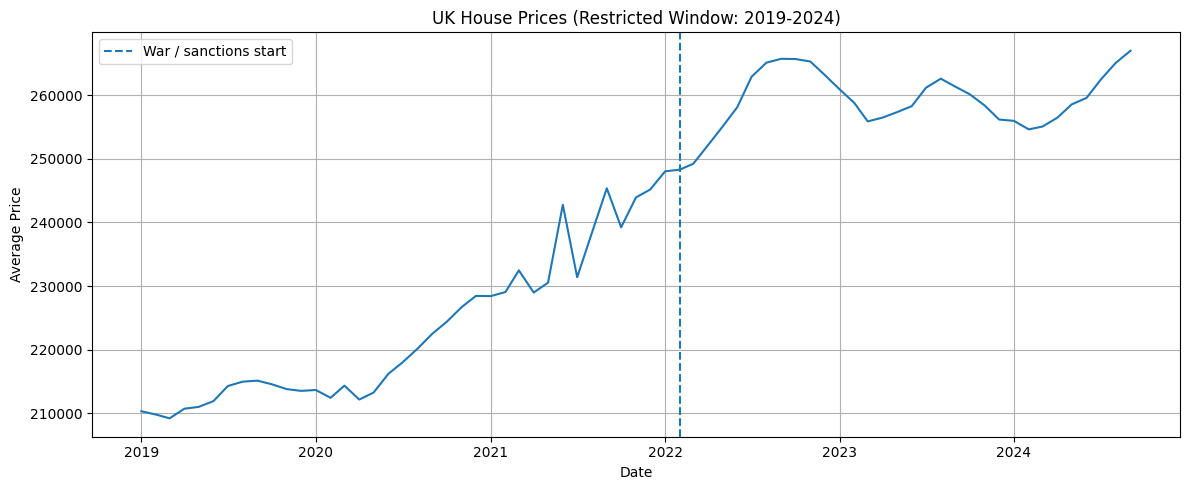

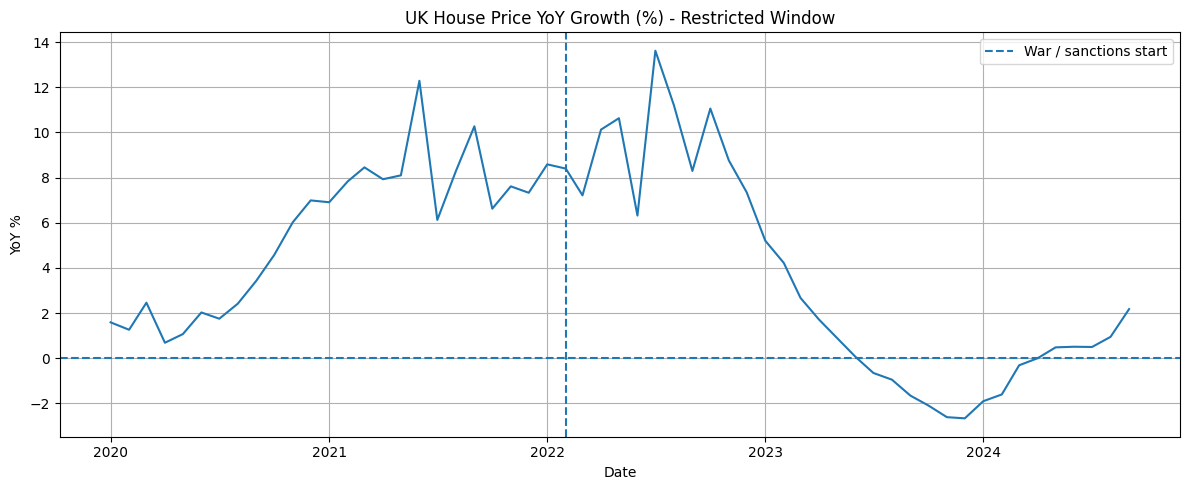

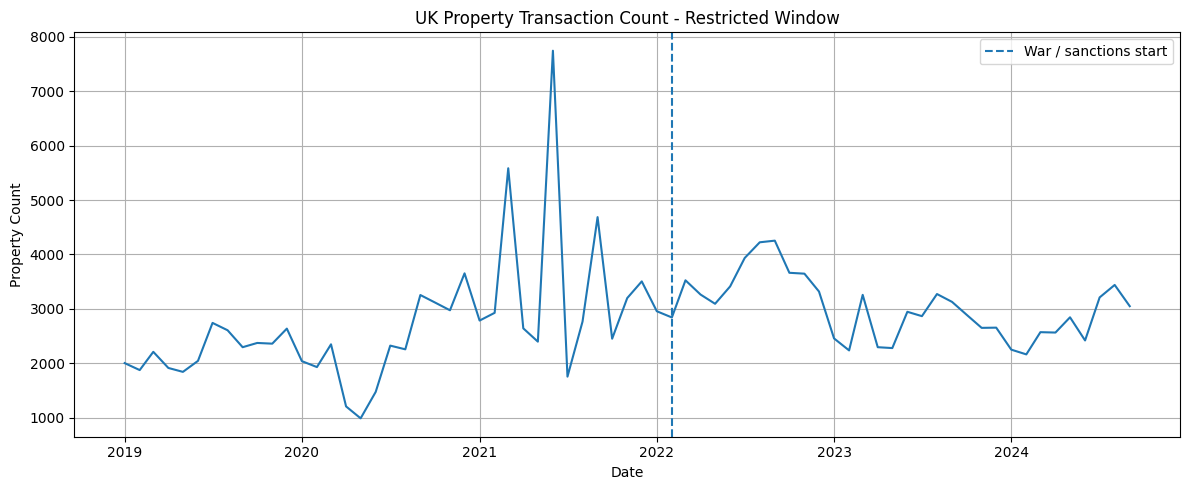

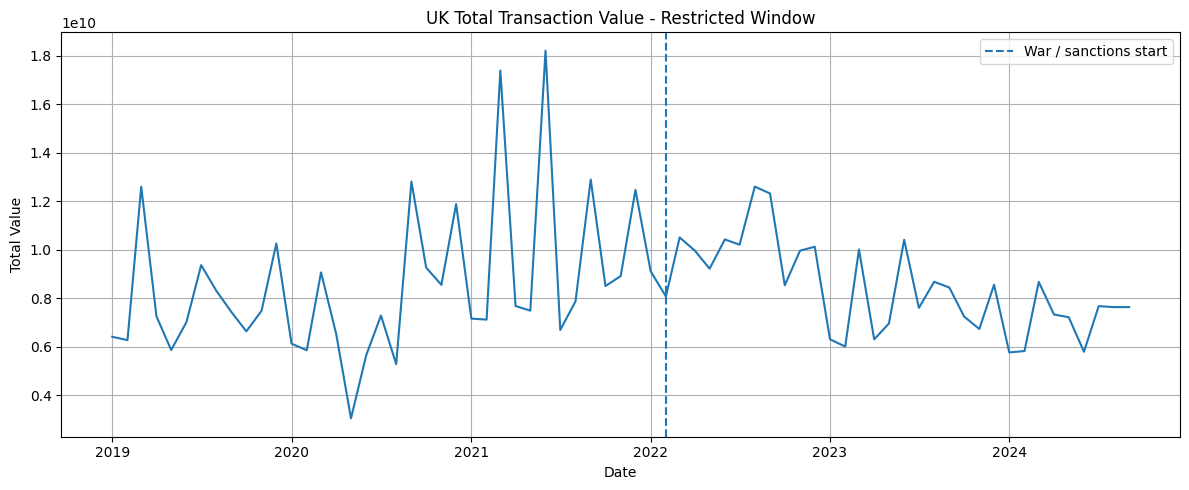

In [6]:

# restricted focus on period around invasion / sanctions
restricted = df[(df["month"] >= "2019-01-01") & (df["month"] <= "2024-09-01")].copy()

# YoY growth inside window
restricted["hpi_yoy_pct"] = restricted["United Kingdom"].pct_change(12) * 100
restricted["transactions_yoy_pct"] = restricted["property_count"].pct_change(12) * 100
restricted["value_yoy_pct"] = restricted["total_value"].pct_change(12) * 100

#regression
before = restricted[(restricted["month"] >= "2019-01-01") & (restricted["month"] < "2022-02-01")].copy()
after = restricted[(restricted["month"] >= "2022-02-03") & (restricted["month"] <= "2024-09-01")].copy()

def summarize_period(data, label):
    first = data.iloc[0]
    last = data.iloc[-1]
    months = (last["month"].year - first["month"].year) * 12 + (last["month"].month - first["month"].month)
    years = months / 12 if months > 0 else 1
    price_change = (last["United Kingdom"] / first["United Kingdom"] - 1) * 100
    annualized = ((last["United Kingdom"] / first["United Kingdom"]) ** (1 / years) - 1) * 100 if months > 0 else 0
    transaction_change = (last["property_count"] / first["property_count"] - 1) * 100
    value_change = (last["total_value"] / first["total_value"] - 1) * 100
    return {"Period": label,
        "Start": first["month"].strftime("%Y-%m"),
        "End": last["month"].strftime("%Y-%m"),
        "House price change (%)": round(price_change, 2),
        "Annualized house price growth (%)": round(annualized, 2),
        "Transaction count change (%)": round(transaction_change, 2),
        "Transaction value change (%)": round(value_change, 2)}

summary = pd.DataFrame([
    summarize_period(before, "Before sanctions (2019-01 to 2022-01)"),
    summarize_period(after, "After sanctions (2022-03 to 2024-09)")])

print("\FOCUSED WINDOW SUMMARY")
print(summary.to_string(index=False))

#extremes
best = restricted.loc[restricted["hpi_yoy_pct"].idxmax(), ["month", "hpi_yoy_pct"]]
worst = restricted.loc[restricted["hpi_yoy_pct"].idxmin(), ["month", "hpi_yoy_pct"]]
print("\nFOCUSED WINDOW EXTREMES")
print(f"Highest YoY house price growth: {best['month'].strftime('%Y-%m')} -> {best['hpi_yoy_pct']:.2f}%")
print(f"Lowest YoY house price growth: {worst['month'].strftime('%Y-%m')} -> {worst['hpi_yoy_pct']:.2f}%")


# plot house prices
plt.figure(figsize=(12,5))
plt.plot(restricted["month"], restricted["United Kingdom"])
plt.axvline(pd.to_datetime("2022-02-01"), linestyle="--", label="War / sanctions start")
plt.title("UK House Prices (Restricted Window: 2019-2024)")
plt.xlabel("Date")
plt.ylabel("Average Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# plot YoY house price growth
plt.figure(figsize=(12,5))
plt.plot(restricted["month"], restricted["hpi_yoy_pct"])
plt.axvline(pd.to_datetime("2022-02-01"), linestyle="--", label="War / sanctions start")
plt.axhline(0, linestyle="--")
plt.title("UK House Price YoY Growth (%) - Restricted Window")
plt.xlabel("Date")
plt.ylabel("YoY %")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# plot transaction count
plt.figure(figsize=(12,5))
plt.plot(restricted["month"], restricted["property_count"])
plt.axvline(pd.to_datetime("2022-02-01"), linestyle="--", label="War / sanctions start")
plt.title("UK Property Transaction Count - Restricted Window")
plt.xlabel("Date")
plt.ylabel("Property Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 4D. Total transaction value
plt.figure(figsize=(12,5))
plt.plot(restricted["month"], restricted["total_value"])
plt.axvline(pd.to_datetime("2022-02-01"), linestyle="--", label="War / sanctions start")
plt.title("UK Total Transaction Value - Restricted Window")
plt.xlabel("Date")
plt.ylabel("Total Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()